In [8]:
import pandas as pd 
import numpy as np
import seaborn as sns

In [9]:
data = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

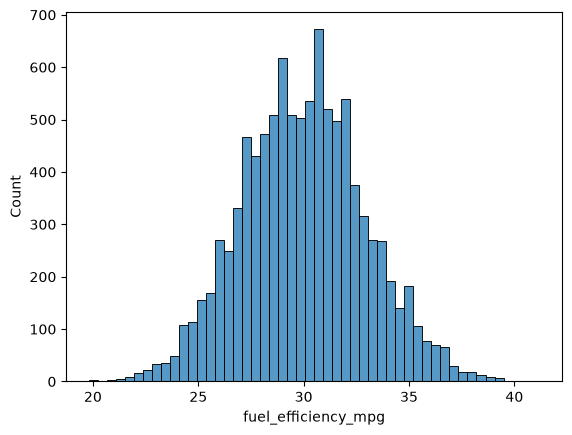

In [10]:
# Look at the fuel_efficiency_mpg variable. Does it have a long tail?

# Answer : Do not have long tail

sns.histplot(data['fuel_efficiency_mpg'] , bins=50)

In [11]:
base = ['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']

In [12]:
# Q 1 / There's one column with missing values. What is it?
# Answer : horsepower

Selected_Col = data[base].isnull().sum()
Selected_Col

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [13]:
# Q 2 / What's the median (50% percentile) for variable 'horsepower'?
# Answer : 254

data['horsepower'].mean()

np.float64(254.44601556505535)

In [14]:
# Q Shuffle the filtered dataset and create the split exactly as in the lecture:

My_New_Data = data[base]

n = len(My_New_Data)

n_Valid = int( n * 0.2 )
n_Test = int( n * 0.2 )
n_Train = n - n_Valid - n_Test

Train_Data = My_New_Data.iloc[:n_Train]
Valid_Data = My_New_Data.iloc[n_Train:n_Train + n_Valid]
Test_Data = My_New_Data.iloc[n_Train + n_Valid:]

idx = np.arange(n)
np.random.shuffle(idx)

Train_Data = My_New_Data.iloc[idx[:n_Train]]
Valid_Data = My_New_Data.iloc[idx[n_Train:n_Train + n_Valid]]
Test_Data = My_New_Data.iloc[idx[n_Train + n_Valid:]]

Train_Data = Train_Data.reset_index(drop=True)
Valid_Data = Valid_Data.reset_index(drop=True)
Test_Data = Test_Data.reset_index(drop=True)

y_Train = Train_Data['fuel_efficiency_mpg'].values
y_Valid = Valid_Data['fuel_efficiency_mpg'].values
y_Test = Test_Data['fuel_efficiency_mpg'].values

y_Train = np.log1p(y_Train)
y_Valid = np.log1p(y_Valid)
y_Test = np.log1p(y_Test)

del Train_Data['fuel_efficiency_mpg']
del Valid_Data['fuel_efficiency_mpg']
del Test_Data['fuel_efficiency_mpg']


My_New_Data.shape , Train_Data.shape , Valid_Data.shape , Test_Data.shape

((10000, 5), (6000, 4), (2000, 4), (2000, 4))

<Axes: ylabel='Count'>

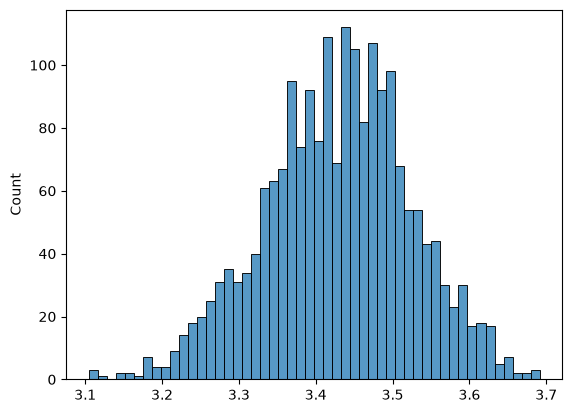

In [15]:
sns.histplot(y_Test , bins=50)

In [16]:
# Q 3

# We need to deal with missing values for the column from Q1.
# We have two options: fill it with 0 or with the mean of this variable.

if 'fuel_efficiency_mpg' in base:
    base.remove('fuel_efficiency_mpg')

def prepare_X(df, fill_value):
    df_num = df[base].copy()
    df_num = df_num.fillna(fill_value) 
    X = df_num.values
    return X

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X_full = np.column_stack([ones, X])

    XTX = X_full.T.dot(X_full)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X_full.T).dot(y)

    return w_full[0], w_full[1:]

def predict_linear_regression(X, w0, w):
    return w0 + X.dot(w)

def rmse(y_true, y_pred):
    se = (y_true - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)


# ==========================================
# fill it with 0
# ==========================================
X_train_0 = prepare_X(Train_Data, fill_value=0)
w0_0, w_0 = train_linear_regression(X_train_0, y_Train)

X_valid_0 = prepare_X(Valid_Data, fill_value=0)
y_pred_0 = predict_linear_regression(X_valid_0, w0_0, w_0)

score_0 = rmse(y_Valid, y_pred_0)
print("RMSE with 0 (horsepower filled with 0)       :", round(score_0, 3))


# ==========================================
# fill it with mean 
# ==========================================

mean_horsepower = Train_Data['horsepower'].mean()

X_train_mean = prepare_X(Train_Data, fill_value=mean_horsepower)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_Train)

X_valid_mean = prepare_X(Valid_Data, fill_value=mean_horsepower)
y_pred_mean = predict_linear_regression(X_valid_mean, w0_mean, w_mean)

score_mean = rmse(y_Valid, y_pred_mean)
print("RMSE with mean (horsepower filled with mean) :", round(score_mean, 3))

RMSE with 0 (horsepower filled with 0)       : 0.072
RMSE with mean (horsepower filled with mean) : 0.072


In [17]:
# Q 4 

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X_full = np.column_stack([ones, X])

    XTX = X_full.T.dot(X_full)
    
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X_full.T).dot(y)

    return w_full[0], w_full[1:]

X_train_0 = prepare_X(Train_Data, fill_value=0)
X_valid_0 = prepare_X(Valid_Data, fill_value=0)


r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

print("Results:")
print("-" * 25)

for r in r_values:
    w0, w = train_linear_regression_reg(X_train_0, y_Train, r=r)
    
    y_pred = predict_linear_regression(X_valid_0, w0, w)
    
    score = rmse(y_Valid, y_pred)
    rounded_score = round(score, 4)
    
    print(f"r: {r:<5} | RMSE: {rounded_score}")

Results:
-------------------------
r: 0     | RMSE: 0.0723
r: 0.01  | RMSE: 0.0723
r: 0.1   | RMSE: 0.0725
r: 1     | RMSE: 0.0737
r: 5     | RMSE: 0.0742
r: 10    | RMSE: 0.0743
r: 100   | RMSE: 0.0744


In [18]:
# Q 5 

# 1. Clearly define the columns.
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

# Initialization function (performs zero-padding as requested by the question)
def prepare_X_loop(df):
    df_num = df[features].copy()
    df_num = df_num.fillna(0) 
    return df_num.values

# Training, Prediction, and Error Calculation Functions
    def train_linear_regression(X, y):
     ones = np.ones(X.shape[0])
     X_full = np.column_stack([ones, X])
     XTX = X_full.T.dot(X_full)
     XTX_inv = np.linalg.inv(XTX)
     w_full = XTX_inv.dot(X_full.T).dot(y)
     return w_full[0], w_full[1:]

def predict_linear_regression(X, w0, w):
    return w0 + X.dot(w)

def rmse(y_true, y_pred):
    se = (y_true - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

# ==========================================
# 2. Iterative loop for stability calculation (without log1p)
# ==========================================
# Replace 'data' with the name of the variable containing your full original data if it has a different name.
n = len(data) 
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

rmse_scores = []
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

for seed in seeds:
# Shuffling data based on the seed
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)
    
    # Data partitioning
    df_train = data.iloc[idx[:n_train]]
    df_val = data.iloc[idx[n_train:n_train + n_val]]
    
# Extract the target y (we removed np.log1p from here)
    y_train = df_train[target].values
    y_val = df_val[target].values
    
    # Preparing features X
    X_train = prepare_X_loop(df_train)
    X_val = prepare_X_loop(df_val)
    
    # Training the model and predicting results
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = predict_linear_regression(X_val, w0, w)
    
    # Calculate the error and save it to the list.
    score = rmse(y_val, y_pred)
    rmse_scores.append(score)
    print(f"Seed {seed}: RMSE = {round(score, 4)}")

# ==========================================
# 3. Final Result
# ==========================================
std_value = np.std(rmse_scores)

print("-" * 25)
print("Standard Deviation:", round(std_value, 3))

Seed 0: RMSE = 2.2392
Seed 1: RMSE = 2.2021
Seed 2: RMSE = 2.1634
Seed 3: RMSE = 2.2044
Seed 4: RMSE = 2.2019
Seed 5: RMSE = 2.2458
Seed 6: RMSE = 2.2697
Seed 7: RMSE = 2.1908
Seed 8: RMSE = 2.2166
Seed 9: RMSE = 2.207
-------------------------
Standard Deviation: 0.029


In [19]:
# Q 6 

features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

def prepare_X_final(df):
    df_num = df[features].copy()
    df_num = df_num.fillna(0) 
    return df_num.values

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X_full = np.column_stack([ones, X])

    XTX = X_full.T.dot(X_full)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X_full.T).dot(y)

    return w_full[0], w_full[1:]

def predict_linear_regression(X, w0, w):
    return w0 + X.dot(w)

def rmse(y_true, y_pred):
    se = (y_true - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

# ==========================================
# 2. Splitting using Seed = 9
# # ==========================================
n = len(data) 
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(9) 
np.random.shuffle(idx)

df_full_train = data.iloc[idx[:n_train + n_val]].reset_index(drop=True)

df_test = data.iloc[idx[n_train + n_val:]].reset_index(drop=True)

# ==========================================
# 3. Extracting the target (y)
# ==========================================

y_full_train = df_full_train[target].values
y_test = df_test[target].values

# ==========================================
# 4. Preparation, Training, and Final Testing
# ==========================================
# Zero-padding
X_full_train = prepare_X_final(df_full_train)
X_test = prepare_X_final(df_test)

# Training with r = 0.001
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

# Prediction on Test Data
y_pred = predict_linear_regression(X_test, w0, w)

# Calculating the final result
final_score = rmse(y_test, y_pred)

print("-" * 25)
print("Final RMSE on Test Dataset:", round(final_score, 3))

-------------------------
Final RMSE on Test Dataset: 2.236
